In [1]:
import pandas as pd
import numpy as np
import os
import json
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

os.makedirs("./output", exist_ok=True)

df = pd.read_csv("../datasets/CICEVSE2024/Power Consumption/EVSE-B-PowerCombined.csv")
df["time"] = pd.to_datetime(df["time"])

features = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]

# ── Filter to only the 3 classes relevant for generator evaluation ────────────
# WHY: The full dataset contains 7 classes. For the generator selection study
# we only need syn-flood (representative distributed attack), Backdoor
# (representative non-distributed attack), and none (benign baseline).
# Keeping unused classes would distort imbalance ratios and contaminate
# the correlation and distribution analyses in Phases 2–5.
TARGET_CLASSES = ["syn-flood", "Backdoor", "none"]
df = df[df["Attack"].isin(TARGET_CLASSES)].copy()

# Reset index after filtering so iloc-based operations remain consistent
df = df.reset_index(drop=True)

classes = df["Attack"].unique().tolist()

print(f"Dataset shape (filtered): {df.shape}")
print(f"\nAttack class distribution:")
print(df["Attack"].value_counts())
print(f"\nUnique attack classes ({df['Attack'].nunique()} total):")
print(df["Attack"].unique())

Dataset shape (filtered): (49017, 10)

Attack class distribution:
Attack
Backdoor     21137
none         14363
syn-flood    13517
Name: count, dtype: int64

Unique attack classes (3 total):
<StringArray>
['syn-flood', 'none', 'Backdoor']
Length: 3, dtype: str


STEP 1.1 — Dataset Shape & Class Distribution
Dataset shape: (49017, 10)

Class sample counts:
Attack
Backdoor     21137
none         14363
syn-flood    13517
Name: count, dtype: int64

Imbalance ratios (majority / class):
  Backdoor              21137 samples   ratio 1.0x
  none                  14363 samples   ratio 1.5x
  syn-flood             13517 samples   ratio 1.6x


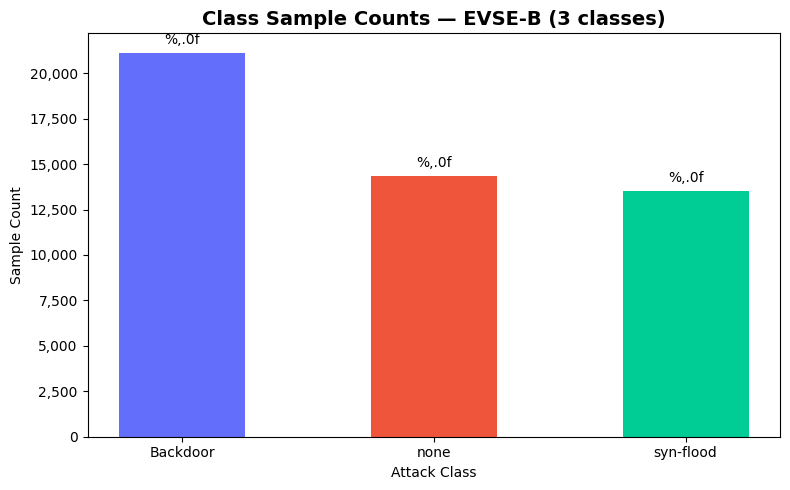

Saved: p1_class_distribution.png

STEP 1.2 — Missing Values & Data Integrity

NaN counts per feature:
shunt_voltage    0
bus_voltage_V    0
current_mA       0
power_mW         0
dtype: int64

Inf counts per feature:
{'shunt_voltage': np.int64(0), 'bus_voltage_V': np.int64(0), 'current_mA': np.int64(0), 'power_mW': np.int64(0)}

Zero-value counts per feature:
{'shunt_voltage': np.int64(0), 'bus_voltage_V': np.int64(0), 'current_mA': np.int64(0), 'power_mW': np.int64(0)}

STEP 1.3 — Temporal Ordering Check
Globally sorted: False
  syn-flood            2023-12-25 22:35:00  →  2023-12-26 02:27:00  sorted=True
  none                 2023-12-26 11:53:00  →  2023-12-26 17:16:00  sorted=False
  Backdoor             2023-12-30 09:51:00  →  2023-12-30 16:20:00  sorted=False

STEP 1.4 — Physical Constraint Residual ε = P - (V × I)

Global ε  mean=0.8888  std=376.3736

ε per class:
             mean       std       min       max
Attack                                         
Backdoor  -3.4521  42

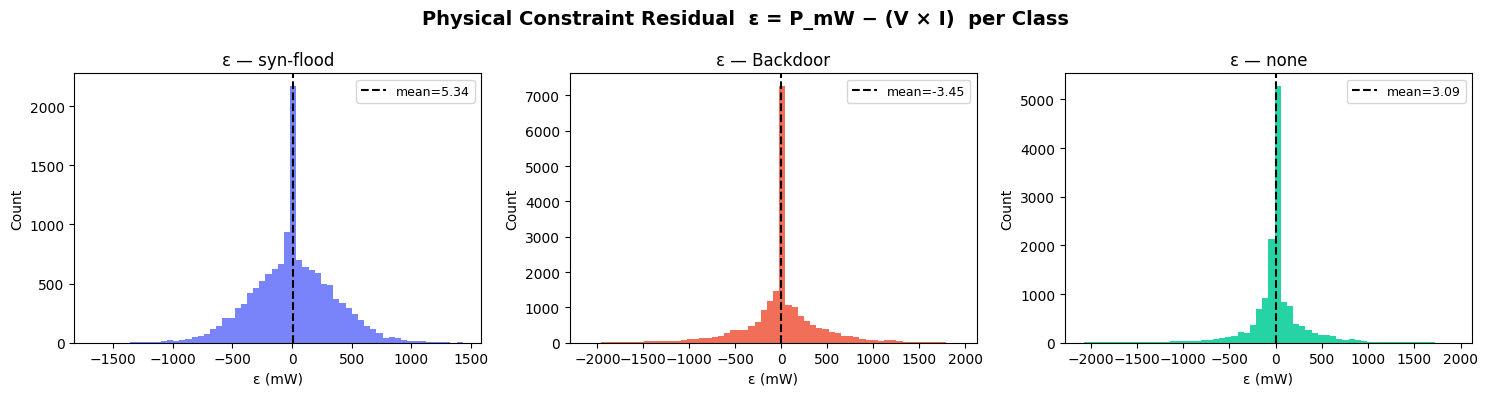

Saved: p1_epsilon_distribution.png

Phase 1 summary → ./output/phase1_summary.csv
    class  n_samples  imbalance_ratio  aug_target  eps_mean  eps_std  eps_lower_3s  eps_upper_3s
 Backdoor      21137             1.00           0   -3.4521 421.0088    -1266.4784     1259.5742
     none      14363             1.47        6774    3.0873 339.6002    -1015.7134     1021.8881
syn-flood      13517             1.56        7620    5.3408 337.5552    -1007.3248     1018.0064

All plots saved to ./output/


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import os

os.makedirs("./output", exist_ok=True)

COLORS = ["#636EFA", "#EF553B", "#00CC96"]

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1.1 — Dataset shape & class distribution
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1.1 — Dataset Shape & Class Distribution")
print("=" * 60)

counts   = df["Attack"].value_counts()
majority = counts.max()

print(f"Dataset shape: {df.shape}")
print(f"\nClass sample counts:\n{counts}")
print("\nImbalance ratios (majority / class):")
for cls, cnt in counts.items():
    ratio = majority / cnt
    flag  = "  ← SEVERE" if ratio > 10 else ("  ← MODERATE" if ratio > 3 else "")
    print(f"  {cls:<20} {cnt:>6} samples   ratio {ratio:.1f}x{flag}")

# PLOT 1.1a — Class distribution
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=COLORS[:len(counts)], width=0.5)
ax.bar_label(bars, fmt="%,.0f", padding=4)
ax.set_title("Class Sample Counts — EVSE-B (3 classes)", fontsize=14, fontweight="bold")
ax.set_xlabel("Attack Class")
ax.set_ylabel("Sample Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("./output/p1_class_distribution.png", dpi=150)
plt.show()
plt.close()

print("Saved: p1_class_distribution.png")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1.2 — Missing values & data integrity check
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1.2 — Missing Values & Data Integrity")
print("=" * 60)
print("\nNaN counts per feature:")
print(df[features].isna().sum())
print("\nInf counts per feature:")
print({f: np.isinf(df[f]).sum() for f in features})
print("\nZero-value counts per feature:")
print({f: (df[f] == 0).sum() for f in features})

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1.3 — Temporal ordering check
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1.3 — Temporal Ordering Check")
print("=" * 60)
print(f"Globally sorted: {df['time'].is_monotonic_increasing}")
for cls in classes:
    sub = df[df["Attack"] == cls]["time"]
    print(f"  {cls:<20} {sub.min()}  →  {sub.max()}  sorted={sub.is_monotonic_increasing}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1.4 — Physical constraint residual ε
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1.4 — Physical Constraint Residual ε = P - (V × I)")
print("=" * 60)

df["epsilon"] = df["power_mW"] - (df["bus_voltage_V"] * df["current_mA"])

eps_stats = df.groupby("Attack")["epsilon"].agg(["mean", "std", "min", "max"]).round(4)
print(f"\nGlobal ε  mean={df['epsilon'].mean():.4f}  std={df['epsilon'].std():.4f}")
print(f"\nε per class:\n{eps_stats}")

eps_thresholds = df.groupby("Attack")["epsilon"].agg(["mean", "std"])
eps_thresholds["lower"] = (eps_thresholds["mean"] - 3 * eps_thresholds["std"]).round(4)
eps_thresholds["upper"] = (eps_thresholds["mean"] + 3 * eps_thresholds["std"]).round(4)
print(f"\n3σ plausibility window:\n{eps_thresholds[['lower', 'upper']]}")

# PLOT 1.4 — ε distribution per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(TARGET_CLASSES):
    eps_vals = df[df["Attack"] == cls]["epsilon"]
    axes[i].hist(eps_vals, bins=60, color=COLORS[i], edgecolor="none", alpha=0.85)
    axes[i].axvline(eps_vals.mean(), color="black", linestyle="--",
                    linewidth=1.5, label=f"mean={eps_vals.mean():.2f}")
    axes[i].set_title(f"ε — {cls}", fontsize=12)
    axes[i].set_xlabel("ε (mW)")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=9)
fig.suptitle("Physical Constraint Residual  ε = P_mW − (V × I)  per Class",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./output/p1_epsilon_distribution.png", dpi=150)
plt.show()
plt.close()
print("Saved: p1_epsilon_distribution.png")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1.6 — Save Phase 1 summary CSV
# ─────────────────────────────────────────────────────────────────────────────
summary_rows = []
for cls, cnt in counts.items():
    eps = df[df["Attack"] == cls]["epsilon"]
    summary_rows.append({
        "class":           cls,
        "n_samples":       cnt,
        "imbalance_ratio": round(majority / cnt, 2),
        # CHANGED: 'target' replaced with 'majority' to calculate augmentation overhead
        "aug_target":      max(0, majority - cnt), 
        "eps_mean":        round(eps.mean(), 4),
        "eps_std":         round(eps.std(), 4),
        "eps_lower_3s":    round(eps.mean() - 3 * eps.std(), 4),
        "eps_upper_3s":    round(eps.mean() + 3 * eps.std(), 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("./output/phase1_summary.csv", index=False)
print("\nPhase 1 summary → ./output/phase1_summary.csv")
print(summary_df.to_string(index=False))
print("\nAll plots saved to ./output/")

STEP 2.1 — Basic Statistics per Feature per Class

── shunt_voltage ──
    class     mean      std   min   25%  median    75%    max
syn-flood 927.7298 134.2086 474.0 907.0   962.0 1008.0 1203.0
 Backdoor 643.2282 130.1743 466.0 545.0   625.0  724.0 1149.0
     none 539.8346  99.7239 417.0 445.0   521.0  593.0  995.0

── bus_voltage_V ──
    class   mean    std   min   25%  median   75%   max
syn-flood 5.1647 0.0095 5.149 5.161   5.161 5.165 5.201
 Backdoor 5.1869 0.0096 5.153 5.181   5.189 5.193 5.205
     none 5.1952 0.0071 5.165 5.189   5.197 5.201 5.209

── current_mA ──
    class     mean      std   min   25%  median    75%    max
syn-flood 927.8048 134.2482 473.0 906.0   963.0 1007.0 1220.0
 Backdoor 643.9736 130.7292 466.0 545.0   626.0  726.0 1101.0
     none 538.5354  98.9083 417.0 445.0   520.0  591.0  991.0

── power_mW ──
    class      mean      std    min    25%  median    75%    max
syn-flood 4796.1249 680.3422 2460.0 4680.0  4980.0 5220.0 6300.0
 Backdoor 3335.8518 664.

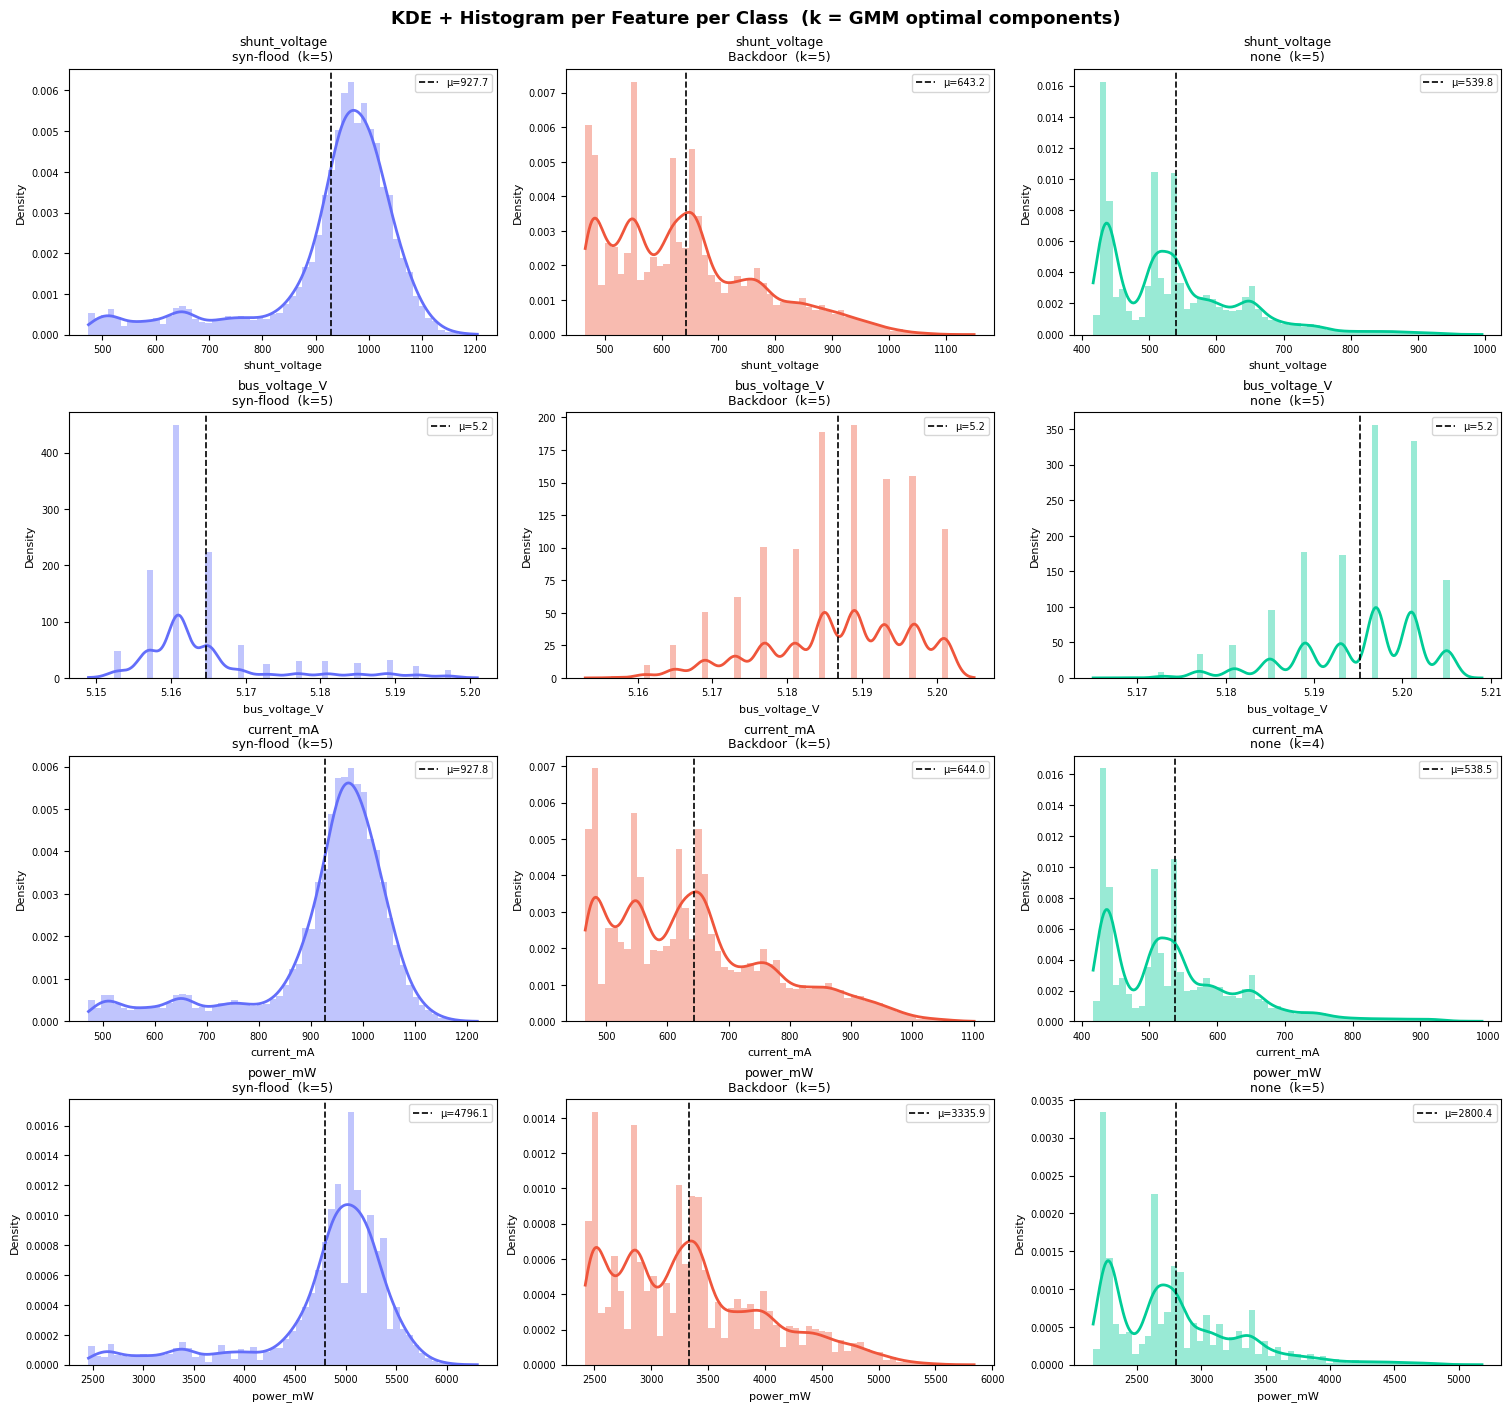

Saved: ./output/p2_kde_histogram_grid.png

Phase 2 complete. Files written:
  phase2_basic_stats.csv
  phase2_shape_descriptors.csv
  phase2_normality_tests.csv
  phase2_gmm_bic.csv
  p2_kde_histogram_grid.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import normaltest
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings("ignore")

os.makedirs("./output", exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.1 — Basic statistics per feature per class
# WHY: Establishes the numerical baseline (mean, spread, range, quartiles)
# for each of the 12 feature-class combinations. These numbers directly
# appear in your paper's dataset characterization table and are the
# reference point against which synthetic data fidelity is measured later.
# EXPECT: Clear numerical differences between classes, especially for
# power_mW and current_mA where syn-flood should show elevated means.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 2.1 — Basic Statistics per Feature per Class")
print("=" * 60)

stats_rows = []
for cls in TARGET_CLASSES:
    sub = df[df["Attack"] == cls][features]
    for feat in features:
        s = sub[feat]
        stats_rows.append({
            "class":   cls,
            "feature": feat,
            "mean":    round(s.mean(), 4),
            "std":     round(s.std(), 4),
            "min":     round(s.min(), 4),
            "25%":     round(s.quantile(0.25), 4),
            "median":  round(s.median(), 4),
            "75%":     round(s.quantile(0.75), 4),
            "max":     round(s.max(), 4),
        })

stats_df = pd.DataFrame(stats_rows)
for feat in features:
    print(f"\n── {feat} ──")
    print(stats_df[stats_df["feature"] == feat]
          .drop(columns="feature")
          .to_string(index=False))

stats_df.to_csv("./output/phase2_basic_stats.csv", index=False)
print("\nSaved: ./output/phase2_basic_stats.csv")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.2 — Shape descriptors: skewness & kurtosis
# WHY: Skewness measures asymmetry; kurtosis measures tail weight.
# Both indicate deviation from a Gaussian distribution.
# Rule of thumb: |skewness| > 1 OR kurtosis > 3 → non-Gaussian
# → CTGAN's mode-specific normalization is motivated over simpler models.
# A high kurtosis (heavy tails) is especially relevant for attack classes
# because rare extreme events (e.g., peak flood values) live in the tails.
# EXPECT: Attack classes (especially syn-flood) to show higher skewness
# and kurtosis than benign (none), confirming non-Gaussian distributions.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2.2 — Shape Descriptors: Skewness & Kurtosis")
print("=" * 60)

shape_rows = []
for cls in TARGET_CLASSES:
    sub = df[df["Attack"] == cls][features]
    for feat in features:
        s = sub[feat]
        skew = round(s.skew(), 4)
        kurt = round(s.kurtosis(), 4)  # excess kurtosis (Gaussian = 0)
        non_gauss = abs(skew) > 1 or kurt > 3
        shape_rows.append({
            "class":       cls,
            "feature":     feat,
            "skewness":    skew,
            "kurtosis":    kurt,
            "non_gaussian": non_gauss,
            "flag":        "← NON-GAUSSIAN" if non_gauss else ""
        })

shape_df = pd.DataFrame(shape_rows)
for feat in features:
    print(f"\n── {feat} ──")
    print(shape_df[shape_df["feature"] == feat]
          .drop(columns="feature")
          .to_string(index=False))

shape_df.to_csv("./output/phase2_shape_descriptors.csv", index=False)
print("\nSaved: ./output/phase2_shape_descriptors.csv")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.3 — Normality test (D'Agostino-K²)
# WHY: Formally tests H₀: the data is normally distributed.
# We use D'Agostino-K² instead of Shapiro-Wilk because all 3 classes
# have n > 5000 — Shapiro-Wilk is unreliable above n=5000 and will
# reject normality for trivially small deviations at large sample sizes.
# D'Agostino-K² combines skewness and kurtosis into a single χ² statistic
# and remains valid for large n.
# p < 0.05 → reject H₀ → distribution is non-Gaussian
# → confirms CTGAN / temporal models over Gaussian-assumption generators.
# EXPECT: Nearly all features to reject normality, especially attack classes.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2.3 — Normality Test (D'Agostino-K²)")
print("=" * 60)

norm_rows = []
for cls in TARGET_CLASSES:
    sub = df[df["Attack"] == cls][features]
    for feat in features:
        s = sub[feat].dropna().values
        stat, p = normaltest(s)
        reject = p < 0.05
        norm_rows.append({
            "class":         cls,
            "feature":       feat,
            "test_stat":     round(stat, 4),
            "p_value":       round(p, 6),
            "reject_normal": reject,
            "conclusion":    "NON-GAUSSIAN" if reject else "Gaussian"
        })

norm_df = pd.DataFrame(norm_rows)
for feat in features:
    print(f"\n── {feat} ──")
    print(norm_df[norm_df["feature"] == feat]
          .drop(columns="feature")
          .to_string(index=False))

norm_df.to_csv("./output/phase2_normality_tests.csv", index=False)
print("\nSaved: ./output/phase2_normality_tests.csv")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.4 — Multimodality detection via GMM + BIC
# WHY: CTGAN uses a Gaussian Mixture Model internally to normalize continuous
# features — it fits k Gaussian components per feature and samples from them
# conditionally. If your real data has k > 1 modes, CTGAN's normalization
# directly models that structure. If k = 1 (unimodal), CTGAN still works
# but a simpler model might suffice.
# BIC (Bayesian Information Criterion): lower = better fit with fewer params.
# We fit k=1..5 and select the k with the lowest BIC.
# EXPECT: Benign (none) may be unimodal (stable idle state).
# Attack classes may show k >= 2 (onset vs. peak vs. decay phases).
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2.4 — Multimodality Detection (GMM + BIC)")
print("=" * 60)

gmm_rows = []
for cls in TARGET_CLASSES:
    sub = df[df["Attack"] == cls][features]
    for feat in features:
        x = sub[feat].dropna().values.reshape(-1, 1)
        bic_scores = []
        for k in range(1, 6):
            gm = GaussianMixture(n_components=k, random_state=42, max_iter=200)
            gm.fit(x)
            bic_scores.append(gm.bic(x))
        best_k = int(np.argmin(bic_scores)) + 1
        gmm_rows.append({
            "class":    cls,
            "feature":  feat,
            "best_k":   best_k,
            "bic_k1":   round(bic_scores[0], 1),
            "bic_k2":   round(bic_scores[1], 1),
            "bic_k3":   round(bic_scores[2], 1),
            "bic_k4":   round(bic_scores[3], 1),
            "bic_k5":   round(bic_scores[4], 1),
            "multimodal": best_k > 1,
            "flag":     f"← MULTIMODAL (k={best_k})" if best_k > 1 else "unimodal"
        })

gmm_df = pd.DataFrame(gmm_rows)
for feat in features:
    print(f"\n── {feat} ──")
    print(gmm_df[gmm_df["feature"] == feat]
          [["class", "best_k", "multimodal", "flag"]]
          .to_string(index=False))

gmm_df.to_csv("./output/phase2_gmm_bic.csv", index=False)
print("\nSaved: ./output/phase2_gmm_bic.csv")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.5 — Visualization: KDE + histogram per feature per class
# WHY: Numerical tests confirm non-Gaussianity, but the plot reveals
# the *shape* — whether it is skewed, heavy-tailed, bimodal, or clipped.
# This is the figure you include in your paper to justify generator choice:
# a bimodal KDE directly motivates CTGAN, a sharp spike motivates TimeGAN.
# Layout: 4 rows (features) × 3 columns (classes) = 12 subplots.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2.5 — KDE + Histogram Plots")
print("=" * 60)

fig, axes = plt.subplots(len(features), len(TARGET_CLASSES),
                          figsize=(15, 14), constrained_layout=True)

for row, feat in enumerate(features):
    for col, cls in enumerate(TARGET_CLASSES):
        ax  = axes[row][col]
        s   = df[df["Attack"] == cls][feat].dropna()
        color = COLORS[col]

        # Histogram (normalized to density)
        ax.hist(s, bins=60, density=True, color=color,
                alpha=0.4, edgecolor="none")

        # KDE overlay
        kde_x = np.linspace(s.min(), s.max(), 300)
        kde   = stats.gaussian_kde(s)
        ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)

        # Mean line
        ax.axvline(s.mean(), color="black", linestyle="--",
                   linewidth=1.2, label=f"μ={s.mean():.1f}")

        # GMM best_k annotation
        k_val = gmm_df[(gmm_df["class"] == cls) &
                       (gmm_df["feature"] == feat)]["best_k"].values[0]
        ax.set_title(f"{feat}\n{cls}  (k={k_val})", fontsize=9)
        ax.set_xlabel(feat, fontsize=8)
        ax.set_ylabel("Density", fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle("KDE + Histogram per Feature per Class  (k = GMM optimal components)",
             fontsize=13, fontweight="bold")
plt.savefig("./output/p2_kde_histogram_grid.png", dpi=150)
plt.show()
plt.close()
print("Saved: ./output/p2_kde_histogram_grid.png")

print("\nPhase 2 complete. Files written:")
print("  phase2_basic_stats.csv")
print("  phase2_shape_descriptors.csv")
print("  phase2_normality_tests.csv")
print("  phase2_gmm_bic.csv")
print("  p2_kde_histogram_grid.png")

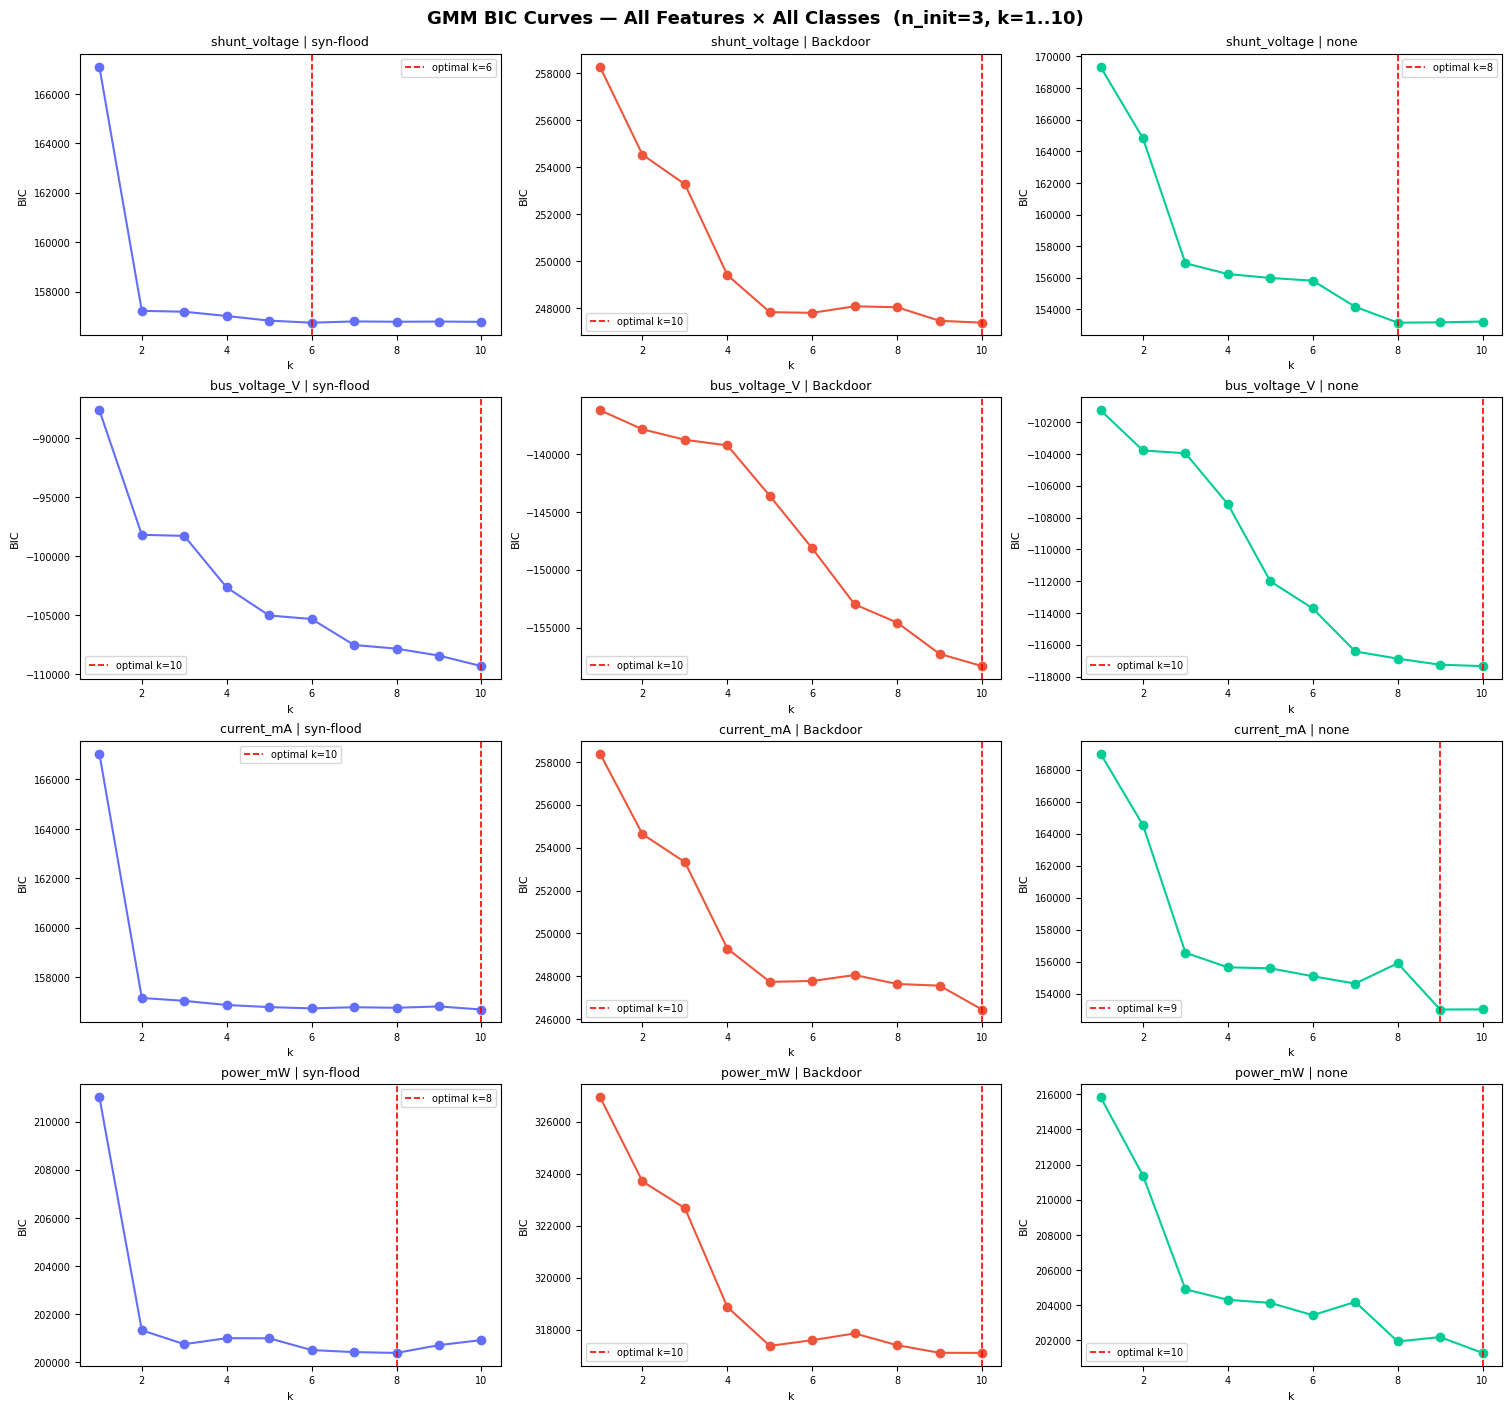


Optimal k per feature per class:
class          Backdoor  none  syn-flood
feature                                 
bus_voltage_V        10    10         10
current_mA           10     9         10
power_mW             10    10          8
shunt_voltage        10     8          6

Saved: ./output/p2_gmm_bic_full.png
Saved: ./output/phase2_gmm_bic_full.csv


In [4]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Run GMM BIC k=1..10 with n_init=3 for all 12 combinations ────────────────
results = []
fig, axes = plt.subplots(len(features), len(TARGET_CLASSES),
                          figsize=(15, 14), constrained_layout=True)

for row, feat in enumerate(features):
    for col, cls in enumerate(TARGET_CLASSES):
        x = df[df["Attack"] == cls][feat].values.reshape(-1, 1)

        bic_scores = []
        for k in range(1, 11):
            gm = GaussianMixture(n_components=k, random_state=42,
                                 max_iter=300, n_init=5)
            gm.fit(x)
            bic_scores.append(gm.bic(x))

        best_k = int(np.argmin(bic_scores)) + 1
        results.append({
            "class":    cls,
            "feature":  feat,
            "best_k":   best_k,
            "multimodal": best_k > 1
        })

        # Plot BIC curve
        ax = axes[row][col]
        ax.plot(range(1, 11), bic_scores, marker="o", linewidth=1.5, color=COLORS[col])
        ax.axvline(best_k, color="red", linestyle="--", linewidth=1.2,
                   label=f"optimal k={best_k}")
        ax.set_title(f"{feat} | {cls}", fontsize=9)
        ax.set_xlabel("k", fontsize=8)
        ax.set_ylabel("BIC", fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle("GMM BIC Curves — All Features × All Classes  (n_init=3, k=1..10)",
             fontsize=13, fontweight="bold")
plt.savefig("./output/p2_gmm_bic_full.png", dpi=150)
plt.show()
plt.close()

# ── Print summary table ───────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print("\nOptimal k per feature per class:")
pivot = results_df.pivot(index="feature", columns="class", values="best_k")
print(pivot.to_string())

results_df.to_csv("./output/phase2_gmm_bic_full.csv", index=False)
print("\nSaved: ./output/p2_gmm_bic_full.png")
print("Saved: ./output/phase2_gmm_bic_full.csv")

In [6]:
txt = '''for syn-flood the k goes up after a while that shows it has different phases and that the order of
samples matters therfore a TimeGAN whould be recommneded.

for Backdoor there k is continusly decreasing therefore that means the values spread out smoothly and continuously
no clear cluster therefore are tabular generator like CTGAN would be recommended.

non Benign: same as backdoor values spread smoothly, no dominant cluster - so tabular generator is recommended.
'''
print(txt)

for syn-flood the k goes up after a while that shows it has different phases and that the order of
samples matters therfore a TimeGAN whould be recommneded.

for Backdoor there k is continusly decreasing therefore that means the values spread out smoothly and continuously
no clear cluster therefore are tabular generator like CTGAN would be recommended.

non Benign: same as backdoor values spread smoothly, no dominant cluster - so tabular generator is recommended.



In [7]:
txt = '''Paper Evaluation:
Improving Intrusion Detection in O-RAN with Synthetic Data Generation: A GAN and SMOTE Approach
- Use Power consumption data from CICEVSE2024 to fix class imbalancy
- Output: all Models fails to improve IDS performance on the target dataset
- SMOTE variants better than GAN variants
- Problem: focus on, class balancing, not generating highly realistic sequences


Synthetic Time-Series Data Generation for Smart Grids Using 3D Autoencoder GAN
- Use household power data and an EV driving dataset and compared with WGAN-GP, VAE-GAN and 3DAE-GAN
- Output: key challange not only class balance, but preserving temporal structure and multivariate dependencies. 
- Result: 3DAE-GAN outperformed WGAN-GP and VAE-GAN
- Problem: focus on smart-grid household and EV time-series generation not attack-class


Generating Synthetic Energy Time Series: A Review
- Review 169 papers on synthetic energy time-series, summary what information are need to make a choice
- Output: for realistic data use-cases GANs and VAEs are widely used
- Results: Consumption data (Markov, wRNG, GAN, NN) | Generation data (Markov, wRNG, GAN, Monte Carlo) | Bettery storage data (Markov, wRNG, NN, GAN, autoregression, clustering) | EV-related data (Markov, wRNG, GAN, autoregression)


Latent Diffusion for Internet of Things Attack Data Generation in Intrusion Detection
- generating synthetic IoT attack data for IDS
- focus on class imbalancy and with more data the training from the IDS is better => better detection
- Result: not perfectly fits in my topic


Beyond Accuracy: Fidelity Evaluation Framework for Synthetic Data in Network Intrusion Detection
- UNSW-NB15 dataset and compare SMOTE, CTGAN, CVAE and trains classifiers on real and synthetic-data
- Output: CVAE give the best accuracy, CTGAN improves minority-class detection, SMOTE highes fidelity score
- Problem: its network data no power-consumption data focus more data => better detection.
- Result: dont fit, focus is on improving IDS because of more data, critical expression in my case.


A Comprehensive survey on generative diffusion Models for structured Data
- Survery about diffusion models which fits to strctured data and feature-based and class conditioned
- Output: For structured data most modern option and alternative to GANs and VAEs
- Results: Tabular Data (TabDDPM, CoDi, STaSy,) | Time Series Data (CSDI, TimeGrad, Scroe Grad)
- Problem: - 


Comprehensive Exploration of Synthetic Data Generation: A Survey.pdf
- 417 synthetic data generation models across 20 model types
- Output: GANs and diffusion models top performers, Markov chians and Bayesian common in rivacy-preserving 
- Results: Images (Diffusio nmodels and GANs) | Sequential data such as text, time series (RNNs) | Very simple data (Markov chains) | Tabluar/structured feature data (VAEs, GANs, diffusion) | Privacy-preseving (Markov-Chains, Bayesian<)
- Problem: just an overall review


A Comprehensive Survey of Synthetic Tabular Data Generation
- Survey for synthetic generation from structured IDS style tabular data
- Output: diffusion models and GAN are important
- Results: imbalanced tabluar data (cGAN, CTAB-GAN, CTGAN, cWGAN) | Mixed-type tabular with heterogeneity (TVAE, VAEM, GOGGLE, TabDDPM, TABDIFF; CoDi, AutoDiff, CTSyn, TABSYN) | Many columns, promptable structure tables (LLM-based models) | High-fidelity tabluar generation (Deffusion models)
- Problem: focus on tabluar synthesis not node-context, power-consumption  or IDS



'''
print(txt)

Paper Evaluation:
Improving Intrusion Detection in O-RAN with Synthetic Data Generation: A GAN and SMOTE Approach
- Use Power consumption data from CICEVSE2024 to fix class imbalancy
- Output: all Models fails to improve IDS performance on the target dataset
- SMOTE variants better than GAN variants
- Problem: focus on, class balancing, not generating highly realistic sequences


Synthetic Time-Series Data Generation for Smart Grids Using 3D Autoencoder GAN
- Use household power data and an EV driving dataset and compared with WGAN-GP, VAE-GAN and 3DAE-GAN
- Output: key challange not only class balance, but preserving temporal structure and multivariate dependencies. 
- Result: 3DAE-GAN outperformed WGAN-GP and VAE-GAN
- Problem: focus on smart-grid household and EV time-series generation not attack-class


Generating Synthetic Energy Time Series: A Review
- Review 169 papers on synthetic energy time-series, summary what information are need to make a choice
- Output: for realistic dat

In [8]:
txt = '''
summary whay information is most usefull:
widly used: GAN, VAE
Choice should based on: Data type, Aggregation level, Temporal resolution and duration, Whether the series is univariate or multivariate, Your use case, What quality you care about most)


Critical issues:
- The Detection gets better bc of the context information from the other nodes not from having more trainings data
- The Evaluation include syntetci data. I have to mention that its just a frist approach and with this result we should evaluate it on Simultated EVSE infrastructure.


The following information about the dataset is also needed to make a good choice:
Data type: tabular, time series, or both.

- Feature types: continuous, categorical, or mixed-type.
- Class imbalance: class counts, minority-class rarity, and whether imbalance is severe.
- Temporal structure: sequence length, sampling rate, periodicity, and long-range dependencies.
- Missing values: how much is missing and whether the missingness is random or structured.
- Inter-feature dependencies: whether columns are weakly or strongly correlated, and whether dependencies are sparse or complex.
- Generation goal: do you want classification improvement, realism, privacy, or downstream predictive usefulness.
- Evaluation target: whether the synthetic data should preserve fidelity, feature importance, robustness, or downstream task performance.

'''

print(txt)


summary whay information is most usefull:
widly used: GAN, VAE
Choice should based on: Data type, Aggregation level, Temporal resolution and duration, Whether the series is univariate or multivariate, Your use case, What quality you care about most)


Critical issues:
- The Detection gets better bc of the context information from the other nodes not from having more trainings data
- The Evaluation include syntetci data. I have to mention that its just a frist approach and with this result we should evaluate it on Simultated EVSE infrastructure.


The following information about the dataset is also needed to make a good choice:
Data type: tabular, time series, or both.

- Feature types: continuous, categorical, or mixed-type.
- Class imbalance: class counts, minority-class rarity, and whether imbalance is severe.
- Temporal structure: sequence length, sampling rate, periodicity, and long-range dependencies.
- Missing values: how much is missing and whether the missingness is random or 

In [19]:
# Feature types: continuous, categorical, or mixed-type.

import pandas as pd
import numpy as np

def auto_feature_type(series, categorical_threshold=20):
    if pd.api.types.is_datetime64_any_dtype(series):
        return "continuous"

    if pd.api.types.is_numeric_dtype(series):
        return "continuous"

    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        n_unique = series.nunique(dropna=True)
        if n_unique <= categorical_threshold:
            return "categorical"
        return "categorical"

    return "categorical"

feature_cols = ["time", "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
                "State", "Attack", "Attack-Group", "Label", "interface"]

feature_summary = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [df[col].dtype for col in feature_cols],
    "n_unique": [df[col].nunique(dropna=True) for col in feature_cols],
    "classification": [auto_feature_type(df[col]) for col in feature_cols]
})

feature_summary

,feature,dtype,n_unique,classification
0,time,datetime64[us],848,continuous
1,shunt_voltage,int64,746,continuous
2,bus_voltage_V,float64,23,continuous
3,current_mA,int64,744,continuous
4,power_mW,int64,124,continuous
5,State,str,2,categorical
6,Attack,str,3,categorical
7,Attack-Group,str,3,categorical
8,Label,str,2,categorical
9,interface,str,3,categorical


In [21]:
txt = ''' Therefore I would need a mixed tabular generator. Who can handle the continuous measurement features and categorical attack metadata at the same time'''
print(txt)

 Therefore I would need a mixed tabular generator. Who can handle the continuous measurement features and categorical attack metadata at the same time


In [22]:
import pandas as pd

counts = df["Attack"].value_counts().sort_values(ascending=False)
majority = counts.iloc[0]
minority = counts.iloc[-1]

imbalance_ratio = majority / minority
minority_share = minority / counts.sum()

severity = (
    "severe" if imbalance_ratio >= 10 else
    "moderate" if imbalance_ratio >= 3 else
    "mild"
)

imbalance_df = pd.DataFrame({
    "class": counts.index,
    "count": counts.values,
    "share": (counts / counts.sum()).values,
    "majority_to_class_ratio": (majority / counts).values
})

print("Class counts:")
print(counts)

print("\nImbalance summary:")
print(f"Majority class: {counts.index[0]} ({majority})")
print(f"Minority class: {minority} ({minority_share:.3%})")
print(f"Majority/minority ratio: {imbalance_ratio:.2f}x")
print(f"Severity: {severity}")

imbalance_df

Class counts:
Attack
Backdoor     21137
none         14363
syn-flood    13517
Name: count, dtype: int64

Imbalance summary:
Majority class: Backdoor (21137)
Minority class: 13517 (27.576%)
Majority/minority ratio: 1.56x
Severity: mild


,class,count,share,majority_to_class_ratio
0,Backdoor,21137,0.431218,1.000000
1,none,14363,0.293021,1.471628
2,syn-flood,13517,0.275761,1.563735


In [25]:
txt = '''
The filtered dataset shows only mild class imbalance, with Backdoor as the majority class and syn-flood as the minority class, yielding a maximum imbalance ratio of approximately 1.6x.'''
print(txt)


The filtered dataset shows only mild class imbalance, with Backdoor as the majority class and syn-flood as the minority class, yielding a maximum imbalance ratio of approximately 1.6x.


In [26]:
import pandas as pd
import numpy as np

df = df.sort_values("time").reset_index(drop=True)

# 1) Sampling interval
df["time_diff"] = df["time"].diff()

sampling_stats = pd.DataFrame({
    "median_delta": [df["time_diff"].median()],
    "mean_delta": [df["time_diff"].mean()],
    "min_delta": [df["time_diff"].min()],
    "max_delta": [df["time_diff"].max()],
    "unique_deltas": [df["time_diff"].nunique(dropna=True)]
})

# 2) Class-wise time span
time_span = df.groupby("Attack")["time"].agg(["min", "max", "count"])
time_span["duration"] = time_span["max"] - time_span["min"]

# 3) Autocorrelation proxy for long-range structure
acf_lags = [1, 5, 10, 50, 100]
acf_rows = []

for feat in ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]:
    s = pd.to_numeric(df[feat], errors="coerce").dropna()
    row = {"feature": feat}
    for lag in acf_lags:
        row[f"lag_{lag}"] = s.autocorr(lag=lag)
    acf_rows.append(row)

acf_df = pd.DataFrame(acf_rows)

print("Sampling stats:")
print(sampling_stats.to_string(index=False))

print("\nTime span by class:")
print(time_span.to_string())

print("\nAutocorrelation proxy:")
print(acf_df.to_string(index=False))

sampling_stats, time_span, acf_df

Sampling stats:
median_delta             mean_delta min_delta       max_delta  unique_deltas
      0 days 0 days 00:00:08.354414    0 days 3 days 16:35:00              6

Time span by class:
                          min                 max  count        duration
Attack                                                                  
Backdoor  2023-12-30 09:51:00 2023-12-30 16:20:00  21137 0 days 06:29:00
none      2023-12-26 11:53:00 2023-12-26 17:16:00  14363 0 days 05:23:00
syn-flood 2023-12-25 22:35:00 2023-12-26 02:27:00  13517 0 days 03:52:00

Autocorrelation proxy:
      feature    lag_1    lag_5   lag_10   lag_50  lag_100
shunt_voltage 0.739723 0.704981 0.705989 0.692926 0.693224
bus_voltage_V 0.769452 0.736977 0.738152 0.725760 0.725896
   current_mA 0.739040 0.705761 0.704026 0.694308 0.691773
     power_mW 0.741321 0.708210 0.705543 0.696695 0.693735


(  median_delta             mean_delta min_delta       max_delta  unique_deltas
 0       0 days 0 days 00:00:08.354414    0 days 3 days 16:35:00              6,
                           min                 max  count        duration
 Attack                                                                  
 Backdoor  2023-12-30 09:51:00 2023-12-30 16:20:00  21137 0 days 06:29:00
 none      2023-12-26 11:53:00 2023-12-26 17:16:00  14363 0 days 05:23:00
 syn-flood 2023-12-25 22:35:00 2023-12-26 02:27:00  13517 0 days 03:52:00,
          feature     lag_1     lag_5    lag_10    lag_50   lag_100
 0  shunt_voltage  0.739723  0.704981  0.705989  0.692926  0.693224
 1  bus_voltage_V  0.769452  0.736977  0.738152  0.725760  0.725896
 2     current_mA  0.739040  0.705761  0.704026  0.694308  0.691773
 3       power_mW  0.741321  0.708210  0.705543  0.696695  0.693735)

In [29]:
txt = '''
The data is recorded in contiguous attack-specific blocks. Within each block, sampling is continuous, but transitions between attack types may involve large time gaps, so the dataset should be treated as multiple continuous segments rather than one uninterrupted sequence.


sequence length: The effective sequence length is the length of each contiguous attack block, not the full filtered dataframe.

sampling rate: The data are not perfectly periodic in time; the time gaps vary, and the median gap can even be zero for adjacent rows, while the mean gap is about 8.35 seconds.

periodicity: There is no clear evidence of a fixed periodic cycle from the available statistics.

long-range dependencies:TThe temporal structure is characterized by contiguous attack-specific blocks. Within each block, the measurements remain relatively stable, while the transition from attack to benign reflects a clear regime change. Therefore, the dominant temporal property is intra-block persistence rather than long-range dependence across the full dataset.

'''
print(txt)


The data is recorded in contiguous attack-specific blocks. Within each block, sampling is continuous, but transitions between attack types may involve large time gaps, so the dataset should be treated as multiple continuous segments rather than one uninterrupted sequence.


sequence length: The effective sequence length is the length of each contiguous attack block, not the full filtered dataframe.

sampling rate: The data are not perfectly periodic in time; the time gaps vary, and the median gap can even be zero for adjacent rows, while the mean gap is about 8.35 seconds.

periodicity: There is no clear evidence of a fixed periodic cycle from the available statistics.

long-range dependencies:TThe temporal structure is characterized by contiguous attack-specific blocks. Within each block, the measurements remain relatively stable, while the transition from attack to benign reflects a clear regime change. Therefore, the dominant temporal property is intra-block persistence rather than

In [30]:
# Missing values: amount and structure
# Assumes df is already loaded and filtered

import pandas as pd
import numpy as np

feature_cols = ["time", "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
                "State", "Attack", "Attack-Group", "Label", "interface"]

# Missingness summary
missing_count = df[feature_cols].isna().sum()
missing_pct = (missing_count / len(df) * 100).round(4)

# Basic structural check: do missing values cluster by class?
missing_by_class = (
    df.assign(any_missing=df[feature_cols].isna().any(axis=1))
      .groupby("Attack")["any_missing"]
      .mean()
      .mul(100)
      .round(4)
)

summary = pd.DataFrame({
    "feature": feature_cols,
    "missing_count": missing_count.values,
    "missing_pct": missing_pct.values,
    "dtype": [df[col].dtype for col in feature_cols]
})

print("Overall missing values per feature:")
print(summary.to_string(index=False))

print("\nRows with at least one missing value:")
print(int(df[feature_cols].isna().any(axis=1).sum()))

print("\nPercentage of rows with at least one missing value:")
print(round(df[feature_cols].isna().any(axis=1).mean() * 100, 4))

print("\nMissingness by attack class (% of rows with any missing value):")
print(missing_by_class.to_string())


Overall missing values per feature:
      feature  missing_count  missing_pct          dtype
         time              0          0.0 datetime64[us]
shunt_voltage              0          0.0          int64
bus_voltage_V              0          0.0        float64
   current_mA              0          0.0          int64
     power_mW              0          0.0          int64
        State              0          0.0            str
       Attack              0          0.0            str
 Attack-Group              0          0.0            str
        Label              0          0.0            str
    interface              0          0.0            str

Rows with at least one missing value:
0

Percentage of rows with at least one missing value:
0.0

Missingness by attack class (% of rows with any missing value):
Attack
Backdoor     0.0
none         0.0
syn-flood    0.0


In [32]:
txt = '''no missing values'''
print(txt)

no missing values


Correlation Matrix — Full Dataset (n=49,017)
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage          1.000         -0.923       0.870     0.850
bus_voltage_V         -0.923          1.000      -0.907    -0.892
current_mA             0.870         -0.907       1.000     0.930
power_mW               0.850         -0.892       0.930     1.000

Correlation Matrix — Benign only (n=14,363)
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage          1.000         -0.735       0.610     0.542
bus_voltage_V         -0.735          1.000      -0.682    -0.640
current_mA             0.610         -0.682       1.000     0.781
power_mW               0.542         -0.640       0.781     1.000

Correlation Matrix — Attack only (n=34,654)
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage          1.000         -0.914       0.850     0.830
bus_voltage_V         -0.914          1.000      -0.894    -0.878
current

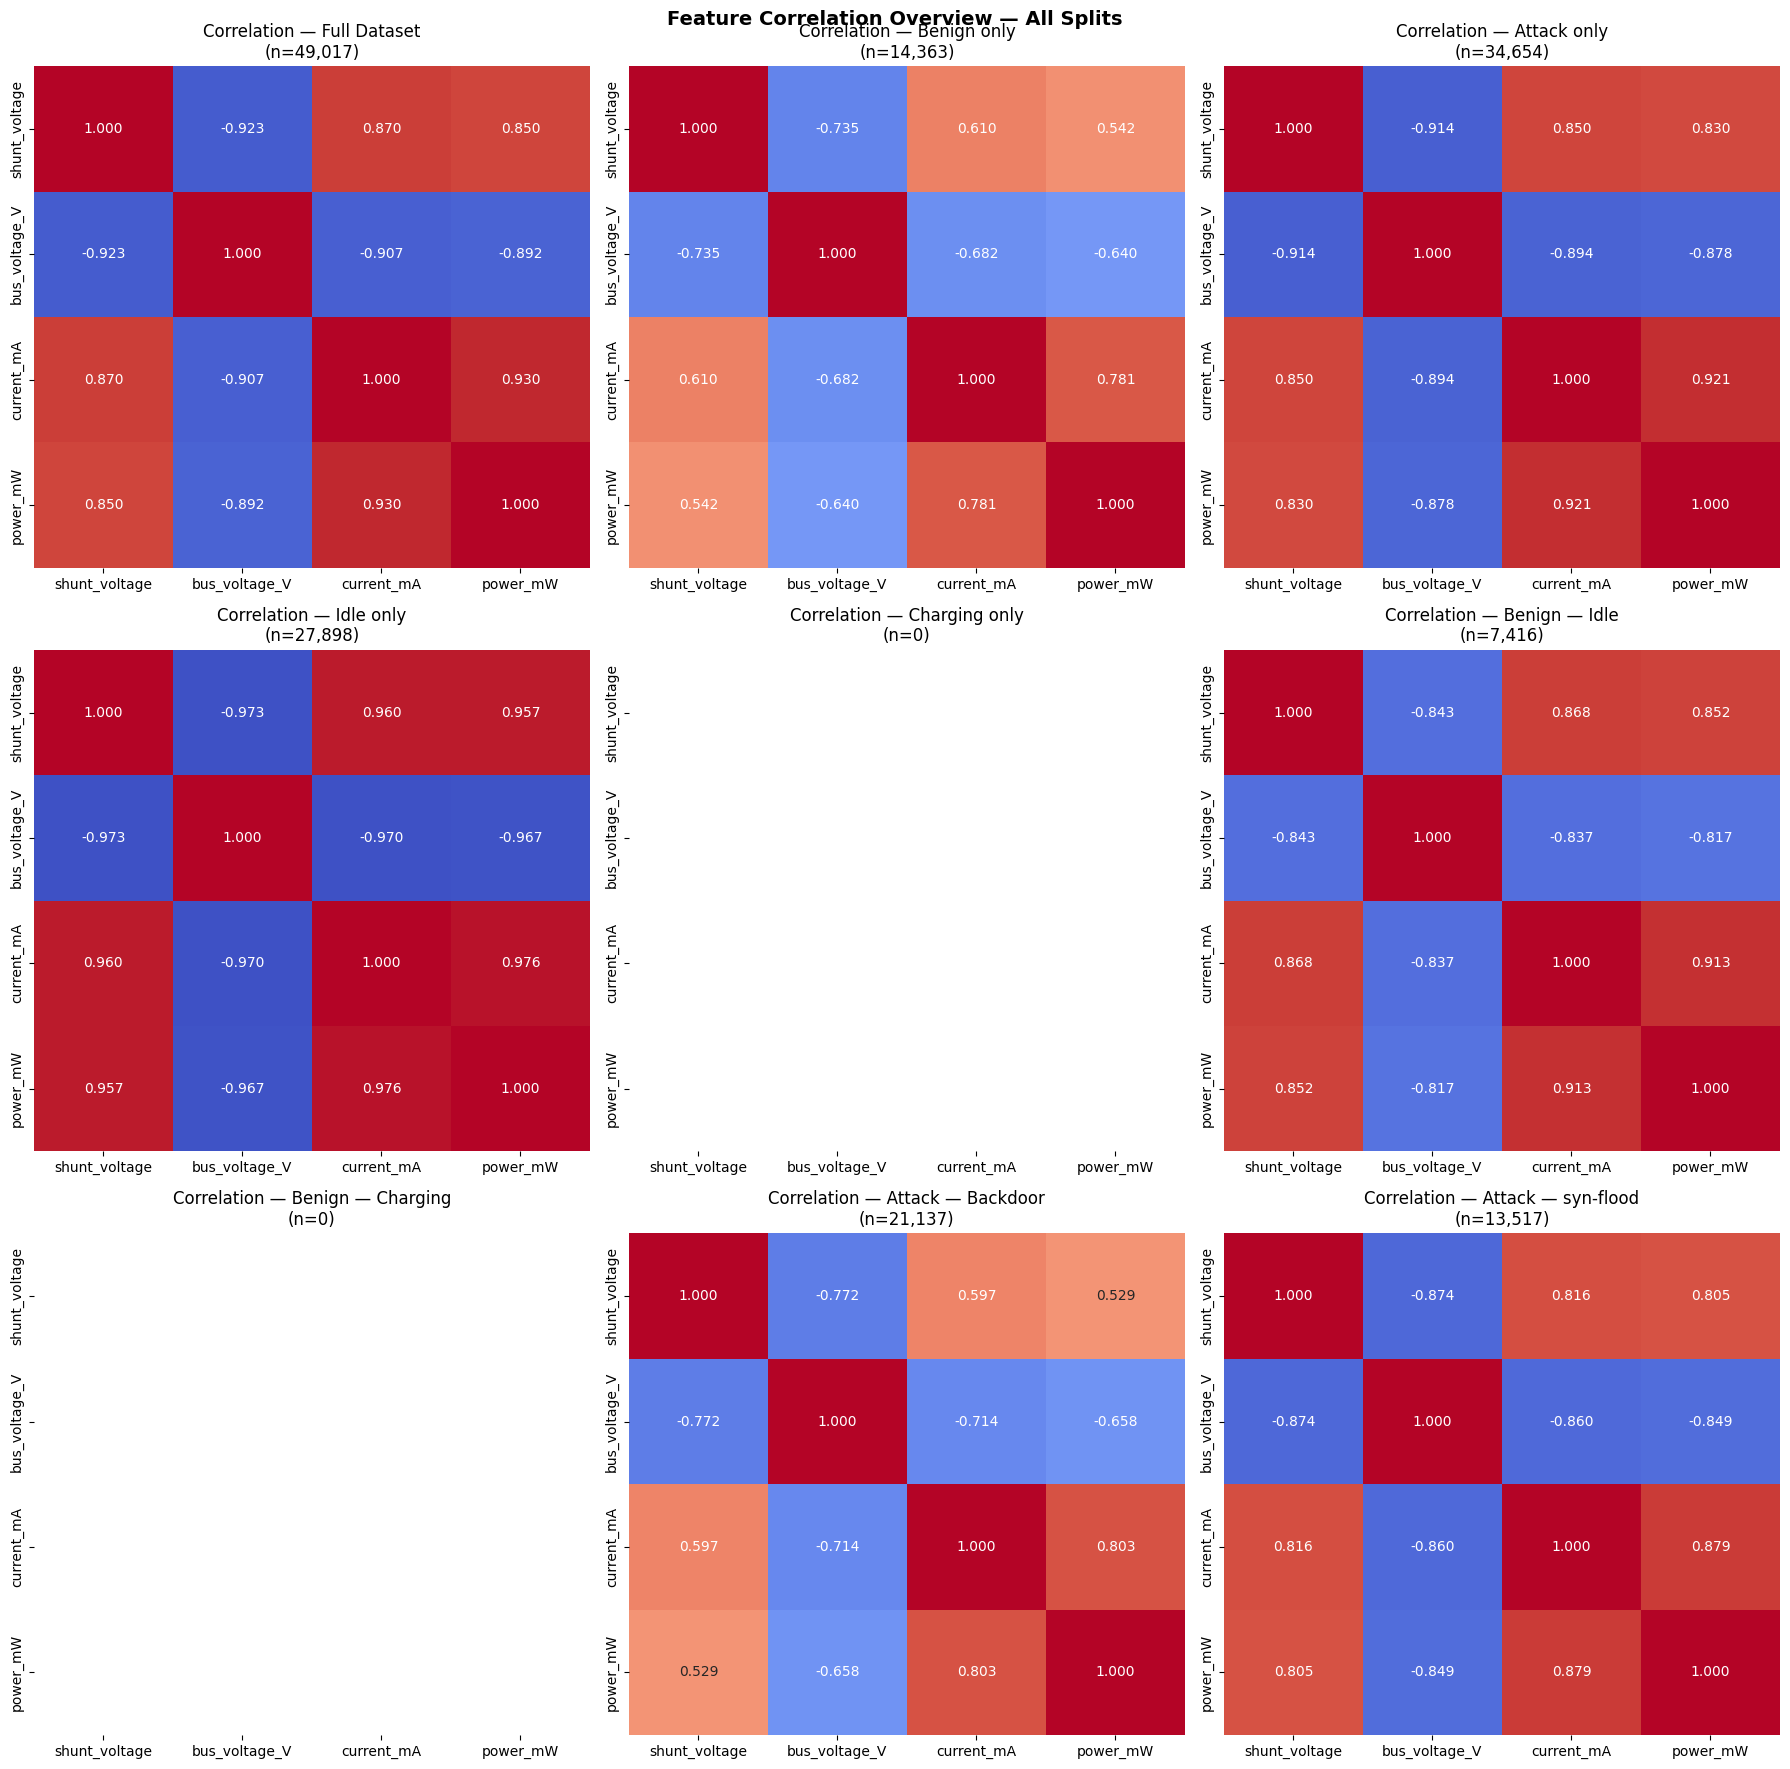

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Use the dataframe already loaded in the notebook.
# If df_power is not available, this cell must be run after the load cell.
csv_path = '../datasets/CICEVSE2024/Power Consumption/EVSE-B-PowerCombined.csv'

SENSOR_COLS = ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW']
attack_col = 'Attack'  # change to 'attack' only if your dataframe uses that exact name

subsets = [
    ('Full Dataset', df),
    ('Benign only', df[df['Label'] == 'benign']),
    ('Attack only', df[df['Label'] == 'attack']),
    ('Idle only', df[df['State'] == 'idle']),
    ('Charging only', df[df['State'] == 'charge']),
    ('Benign — Idle', df[(df['Label'] == 'benign') & (df['State'] == 'idle')]),
    ('Benign — Charging', df[(df['Label'] == 'benign') & (df['State'] == 'charge')]),
    ('Attack — Backdoor', df[df[attack_col] == 'Backdoor']),
    ('Attack — syn-flood', df[df[attack_col] == 'syn-flood']),
]

n_cols = 3
n_rows = (len(subsets) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, (label, subset) in enumerate(subsets):
    corr = subset[SENSOR_COLS].corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        ax=axes[i],
        cbar=False
    )
    axes[i].set_title(f'Correlation — {label}\n(n={len(subset):,})')

    print('=' * 55)
    print(f'Correlation Matrix — {label} (n={len(subset):,})')
    print('=' * 55)
    print(corr.round(3).to_string())
    print()

for j in range(len(subsets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Correlation Overview — All Splits', fontsize=14, fontweight='bold')
plt.tight_layout()

out_dir = '../datasets/CICEVSE2024/synthetic_nodes'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
txt = '''Inter-feature dependencies: whether columns are weakly or strongly correlated, and whether dependencies are sparse or complex.
answer: strongly correlated, complex, and not sparse.
'''
print(txt)

Inter-feature dependencies: whether columns are weakly or strongly correlated, and whether dependencies are sparse or complex.
answer: strongly correlated, complex, and not sparse.



In [50]:
txt = '''Generation goal: do you want classification improvement, realism, privacy, or downstream predictive usefulness.

In this work, synthetic data generation is treated as an upstream task, since the objective is to reproduce realistic sensor-level data distributions and temporal structure before any downstream modeling is applied
'''

print(txt)

Generation goal: do you want classification improvement, realism, privacy, or downstream predictive usefulness.

In this work, synthetic data generation is treated as an upstream task, since the objective is to reproduce realistic sensor-level data distributions and temporal structure before any downstream modeling is applied



In [53]:
txt = '''Evaluation target: whether the synthetic data should preserve fidelity, feature importance, robustness, or downstream task performance.#

Answer: The primary evaluation target is fidelity, meaning the synthetic data should preserve the observed distributions, inter-feature dependencies, and class-specific regimes of the original data.
'''

print(txt)

Evaluation target: whether the synthetic data should preserve fidelity, feature importance, robustness, or downstream task performance.#

Answer: The primary evaluation target is fidelity, meaning the synthetic data should preserve the observed distributions, inter-feature dependencies, and class-specific regimes of the original data.



In [2]:
txt = '''
TabDDPM outperformt GAN- und VAE-Baselines in Trainingsstabilität, multimodaler Verteilungsabdeckung und Privacy-Metriken, was es für Fidelity-orientierte Anwendungen wie die vorliegende Arbeit attraktiv macht
'''
print(txt)


TabDDPM outperformt GAN- und VAE-Baselines in Trainingsstabilität, multimodaler Verteilungsabdeckung und Privacy-Metriken, was es für Fidelity-orientierte Anwendungen wie die vorliegende Arbeit attraktiv macht



In [2]:
txt = '''
- denoising autoenconder (Hyper parameter trainieren, selbes model dann immer für die Syntethische erweiterung nutzen.)
- VAE eher ungeeignet.
- GAN einfaches nutzen.



Validierung:
ML klassifierung (RF) (Minimum decreas, aber über RF kann ich sehen wie stark einfluss Feature xy hat)
1 eval. Nur CIC datensatz
2 eval. CIC + Autoecnode
3 eval CIC + Autoencodner + Kontext


TableGAN und Denoising Autoencoder
'''

print(txt)



- denoising autoenconder (Hyper parameter trainieren, selbes model dann immer für die Syntethische erweiterung nutzen.)
- VAE eher ungeeignet.
- GAN einfaches nutzen.



Validierung:
ML klassifierung (RF) (Minimum decreas, aber über RF kann ich sehen wie stark einfluss Feature xy hat)
1 eval. Nur CIC datensatz
2 eval. CIC + Autoecnode
3 eval CIC + Autoencodner + Kontext


TableGAN und Denoising Autoencoder

